In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df_raw = pd.read_csv("../data/freshretailnet_muestra_100k_secuencial.csv",sep=",")

print(f"Filas: {df_raw.shape[0]:,}")
print(f"Columnas: {df_raw.shape[1]:,}")
display(df_raw.head())

Filas: 100,000
Columnas: 24


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,hours_sale,stock_hour6_22_cnt,hours_stock_status,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level,nombre_producto,nombre_tienda,nombre_categoria_n1,nombre_categoria_n2,nombre_categoria_n3
0,0,0,0,5,6,65,38,2024-03-28,0.1,[0. 0. 0. 0. 0. 0. 0. 0.1 0. 0. 0. 0...,0,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0],1.0,0,0,1.6999,15.48,73.54,1.97,Producto 0105,Tienda 001,Categoría N1 023,Categoría N2 040,Categoría N3 122
1,0,0,0,5,6,65,38,2024-03-29,0.1,[0. 0. 0. 0. 0. 0. 0.1 0. 0. 0. 0. 0...,1,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1],1.0,0,0,3.0190,15.08,76.56,1.71,Producto 0105,Tienda 001,Categoría N1 023,Categoría N2 040,Categoría N3 122
2,0,0,0,5,6,65,38,2024-03-30,0.0,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,0,[1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0],1.0,1,0,2.0942,15.91,76.47,1.73,Producto 0105,Tienda 001,Categoría N1 023,Categoría N2 040,Categoría N3 122
3,0,0,0,5,6,65,38,2024-03-31,0.1,[0. 0. 0. 0. 0. 0. 0. 0. 0.1 0. 0. 0...,11,[0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1],1.0,1,0,1.5618,16.13,77.40,1.76,Producto 0105,Tienda 001,Categoría N1 023,Categoría N2 040,Categoría N3 122
4,0,0,0,5,6,65,38,2024-04-01,0.2,[0. 0. 0. 0. 0. 0. 0.1 0. 0. 0. 0. 0...,8,[1 1 1 1 1 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1],1.0,0,0,3.5386,15.37,78.26,1.25,Producto 0105,Tienda 001,Categoría N1 023,Categoría N2 040,Categoría N3 122


In [19]:
COLUMNAS_MODELO_BASE = [
    "dt",
    "product_id",
    "store_id",
    "first_category_id",
    "second_category_id",
    "third_category_id",
    "sale_amount",
    "stock_hour6_22_cnt",
    "hours_stock_status",
    "discount",
    "holiday_flag",
    "activity_flag",
    "nombre_producto",
    "nombre_tienda",
    "nombre_categoria_n1",
    "nombre_categoria_n2",
    "nombre_categoria_n3",
]

columnas_existentes = [col for col in COLUMNAS_MODELO_BASE if col in df_raw.columns]
df = df_raw[columnas_existentes].copy()

df["dt"] = pd.to_datetime(df["dt"], errors="coerce")

columnas_categoricas = [
    "product_id",
    "store_id",
    "first_category_id",
    "second_category_id",
    "third_category_id",
    "holiday_flag",
    "activity_flag",
]

for col in columnas_categoricas:
    if col in df.columns:
        df[col] = df[col].astype("category")

print("Columnas seleccionadas:")
print(df.columns.tolist())
display(df.head())

Columnas seleccionadas:
['dt', 'product_id', 'store_id', 'first_category_id', 'second_category_id', 'third_category_id', 'sale_amount', 'stock_hour6_22_cnt', 'hours_stock_status', 'discount', 'holiday_flag', 'activity_flag', 'nombre_producto', 'nombre_tienda', 'nombre_categoria_n1', 'nombre_categoria_n2', 'nombre_categoria_n3']


,dt,product_id,store_id,first_category_id,second_category_id,third_category_id,sale_amount,stock_hour6_22_cnt,hours_stock_status,discount,holiday_flag,activity_flag,nombre_producto,nombre_tienda,nombre_categoria_n1,nombre_categoria_n2,nombre_categoria_n3
0,2024-03-28,38,0,5,6,65,0.1,0,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0],1.0,0,0,Producto 0105,Tienda 001,Categoría N1 023,Categoría N2 040,Categoría N3 122
1,2024-03-29,38,0,5,6,65,0.1,1,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1],1.0,0,0,Producto 0105,Tienda 001,Categoría N1 023,Categoría N2 040,Categoría N3 122
2,2024-03-30,38,0,5,6,65,0.0,0,[1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0],1.0,1,0,Producto 0105,Tienda 001,Categoría N1 023,Categoría N2 040,Categoría N3 122
3,2024-03-31,38,0,5,6,65,0.1,11,[0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1],1.0,1,0,Producto 0105,Tienda 001,Categoría N1 023,Categoría N2 040,Categoría N3 122
4,2024-04-01,38,0,5,6,65,0.2,8,[1 1 1 1 1 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1],1.0,0,0,Producto 0105,Tienda 001,Categoría N1 023,Categoría N2 040,Categoría N3 122


## 4. Revisión general

Bloques adaptados del notebook de logística: estructura, valores nulos, duplicados y resumen estadístico.

In [20]:
df.info()

print("\nValores nulos por columna:")
display(df.isna().sum().sort_values(ascending=False).to_frame("nulos"))

print(f"\nFilas duplicadas: {df.duplicated().sum():,}")

print("\nResumen estadístico de variables numéricas:")
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   dt                   100000 non-null  datetime64[us]
 1   product_id           100000 non-null  category      
 2   store_id             100000 non-null  category      
 3   first_category_id    100000 non-null  category      
 4   second_category_id   100000 non-null  category      
 5   third_category_id    100000 non-null  category      
 6   sale_amount          100000 non-null  float64       
 7   stock_hour6_22_cnt   100000 non-null  int64         
 8   hours_stock_status   100000 non-null  str           
 9   discount             100000 non-null  float64       
 10  holiday_flag         100000 non-null  category      
 11  activity_flag        100000 non-null  category      
 12  nombre_producto      100000 non-null  str           
 13  nombre_tienda        10000

,nulos
dt,0
product_id,0
store_id,0
first_category_id,0
second_category_id,0
third_category_id,0
sale_amount,0
stock_hour6_22_cnt,0
hours_stock_status,0
discount,0



Filas duplicadas: 0

Resumen estadístico de variables numéricas:


,dt,sale_amount,stock_hour6_22_cnt,discount
count,100000,100000.000000,100000.000000,100000.000000
mean,2024-05-11 11:54:14.400000,1.031985,3.150360,0.914588
min,2024-03-28 00:00:00,0.000000,0.000000,0.358000
25%,2024-04-19 00:00:00,0.400000,0.000000,0.851000
50%,2024-05-11 00:00:00,0.700000,0.000000,0.988000
75%,2024-06-03 00:00:00,1.200000,6.000000,1.000000
max,2024-06-25 00:00:00,22.900000,16.000000,1.000000
std,NaN,1.187224,4.458454,0.113639


In [21]:
df = df.sort_values(["store_id", "product_id", "dt"]).reset_index(drop=True)

df["anio"] = df["dt"].dt.year
df["mes"] = df["dt"].dt.month
df["dia_mes"] = df["dt"].dt.day
df["dia_semana"] = df["dt"].dt.dayofweek
df["fin_semana"] = (df["dia_semana"] >= 5).astype(int)

grupo = df.groupby(["store_id", "product_id"], observed=True)

df["venta_lag_1"] = grupo["sale_amount"].shift(1)
df["venta_lag_7"] = grupo["sale_amount"].shift(7)
df["venta_promedio_7d"] = grupo["sale_amount"].transform(
    lambda s: s.shift(1).rolling(7, min_periods=1).mean()
)
df["venta_promedio_14d"] = grupo["sale_amount"].transform(
    lambda s: s.shift(1).rolling(14, min_periods=1).mean()
)
df["stock_lag_1"] = grupo["stock_hour6_22_cnt"].shift(1)

print("Variables temporales creadas correctamente.")
display(df.head(-1))

Variables temporales creadas correctamente.


,dt,product_id,store_id,first_category_id,second_category_id,third_category_id,sale_amount,stock_hour6_22_cnt,hours_stock_status,discount,holiday_flag,activity_flag,nombre_producto,nombre_tienda,nombre_categoria_n1,nombre_categoria_n2,nombre_categoria_n3,anio,mes,dia_mes,dia_semana,fin_semana,venta_lag_1,venta_lag_7,venta_promedio_7d,venta_promedio_14d,stock_lag_1
0,2024-03-28,4,0,29,78,82,0.5,13,[1 1 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1],0.882,0,1,Producto 0109,Tienda 001,Categoría N1 018,Categoría N2 058,Categoría N3 137,2024,3,28,3,0,NaN,NaN,NaN,NaN,NaN
1,2024-03-29,4,0,29,78,82,1.3,5,[1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1],0.882,0,1,Producto 0109,Tienda 001,Categoría N1 018,Categoría N2 058,Categoría N3 137,2024,3,29,4,0,0.5,NaN,0.500000,0.500000,13.0
2,2024-03-30,4,0,29,78,82,5.3,0,[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0],0.882,1,1,Producto 0109,Tienda 001,Categoría N1 018,Categoría N2 058,Categoría N3 137,2024,3,30,5,1,1.3,NaN,0.900000,0.900000,5.0
3,2024-03-31,4,0,29,78,82,4.2,0,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0],0.879,1,1,Producto 0109,Tienda 001,Categoría N1 018,Categoría N2 058,Categoría N3 137,2024,3,31,6,1,5.3,NaN,2.366667,2.366667,0.0
4,2024-04-01,4,0,29,78,82,0.7,0,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0],0.882,0,1,Producto 0109,Tienda 001,Categoría N1 018,Categoría N2 058,Categoría N3 137,2024,4,1,0,0,4.2,NaN,2.825000,2.825000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,2024-06-20,841,46,0,13,27,0.2,13,[1 1 1 1 1 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1],1.000,0,0,Producto 0258,Tienda 012,Categoría N1 001,Categoría N2 005,Categoría N3 101,2024,6,20,3,0,0.2,0.0,0.200000,0.271429,11.0
99995,2024-06-21,841,46,0,13,27,0.3,7,[1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1],1.000,0,0,Producto 0258,Tienda 012,Categoría N1 001,Categoría N2 005,Categoría N3 101,2024,6,21,4,0,0.2,0.3,0.228571,0.242857,13.0
99996,2024-06-22,841,46,0,13,27,0.2,0,[1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0],1.000,1,0,Producto 0258,Tienda 012,Categoría N1 001,Categoría N2 005,Categoría N3 101,2024,6,22,5,1,0.3,0.1,0.228571,0.250000,7.0
99997,2024-06-23,841,46,0,13,27,0.3,0,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0],1.000,1,0,Producto 0258,Tienda 012,Categoría N1 001,Categoría N2 005,Categoría N3 101,2024,6,23,6,1,0.2,0.4,0.242857,0.250000,0.0


Resumen de sale_amount:


,sale_amount
count,100000.000000
mean,1.031985
std,1.187224
min,0.000000
25%,0.400000
50%,0.700000
75%,1.200000
max,22.900000


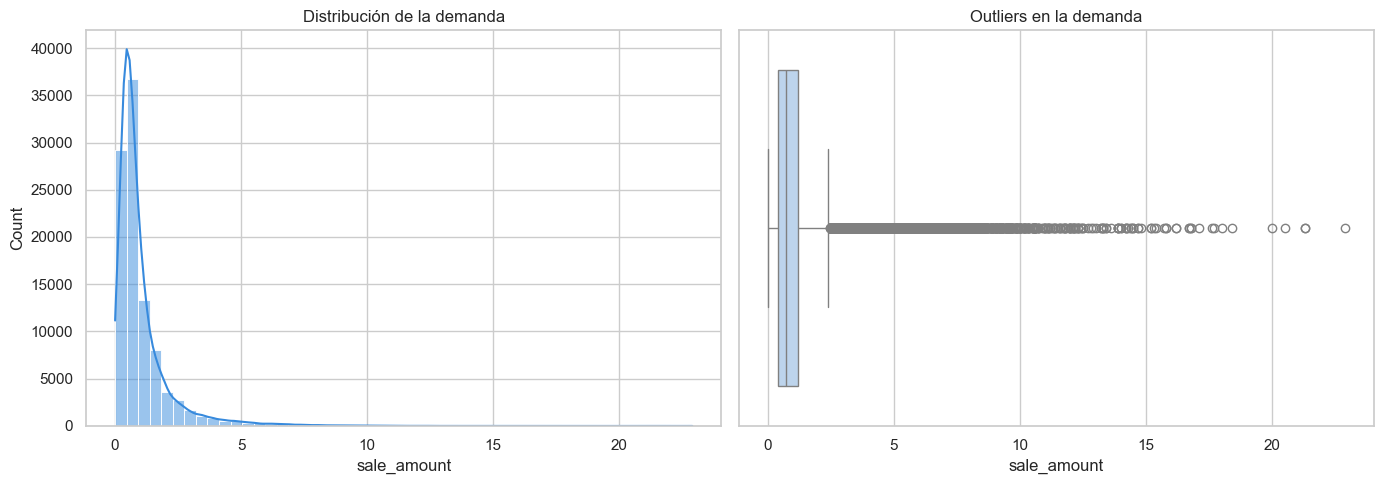

In [22]:
print("Resumen de sale_amount:")
display(df["sale_amount"].describe().to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["sale_amount"], bins=50, kde=True, ax=axes[0], color="#378ADD")
axes[0].set_title("Distribución de la demanda")
axes[0].set_xlabel("sale_amount")

sns.boxplot(x=df["sale_amount"], ax=axes[1], color="#B5D4F4")
axes[1].set_title("Outliers en la demanda")
axes[1].set_xlabel("sale_amount")

plt.tight_layout()
plt.show()

## 7. Comportamiento temporal de la demanda

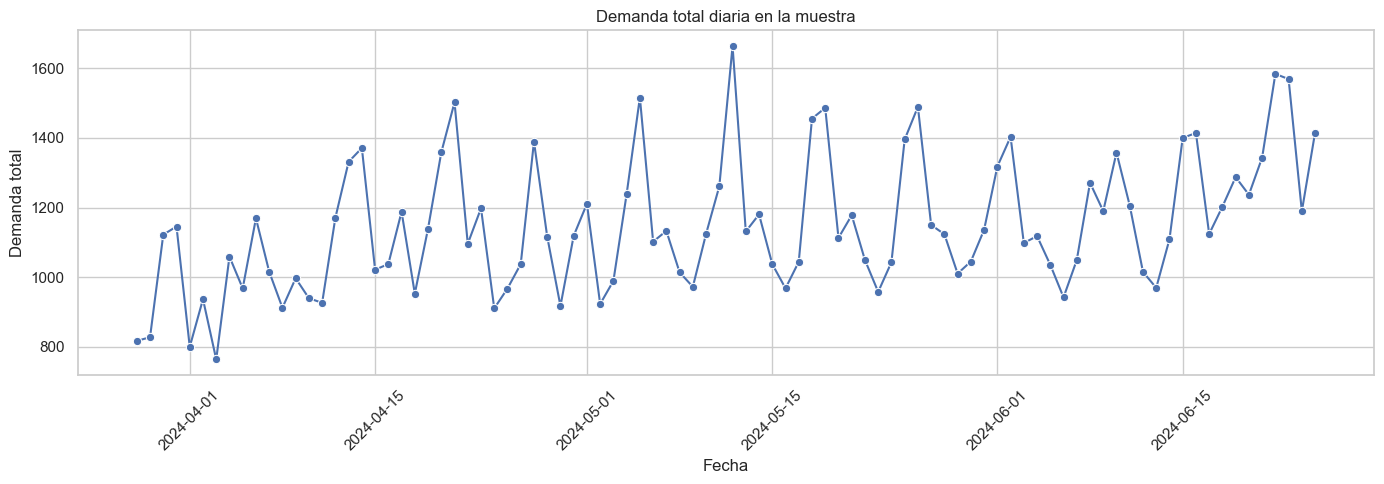

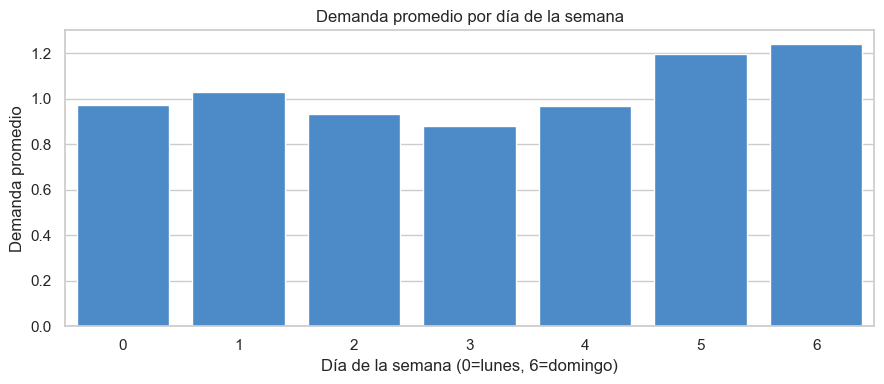

In [23]:
ventas_diarias = df.groupby("dt", as_index=False)["sale_amount"].sum()

plt.figure(figsize=(14, 5))
sns.lineplot(data=ventas_diarias, x="dt", y="sale_amount", marker="o")
plt.title("Demanda total diaria en la muestra")
plt.xlabel("Fecha")
plt.ylabel("Demanda total")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

demanda_dia_semana = df.groupby("dia_semana", as_index=False)["sale_amount"].mean()

plt.figure(figsize=(9, 4))
sns.barplot(data=demanda_dia_semana, x="dia_semana", y="sale_amount", color="#378ADD")
plt.title("Demanda promedio por día de la semana")
plt.xlabel("Día de la semana (0=lunes, 6=domingo)")
plt.ylabel("Demanda promedio")
plt.tight_layout()
plt.show()

## 8. Productos, tiendas y categorías con mayor demanda

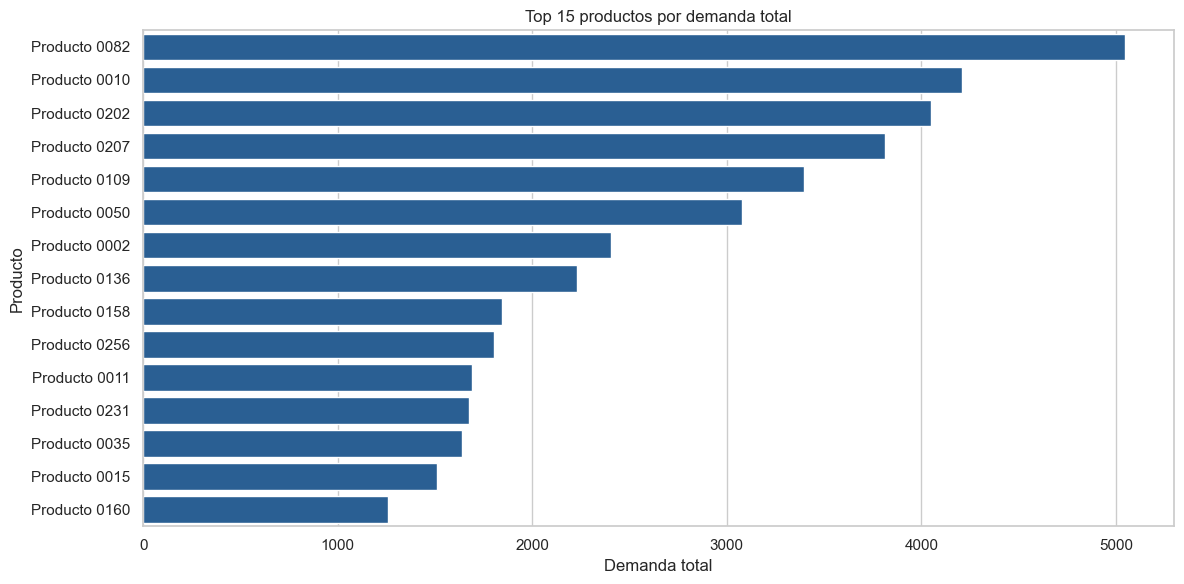

,product_id,nombre_producto,sale_amount
0,300,Producto 0082,5046.53
1,117,Producto 0010,4208.80
2,691,Producto 0202,4050.50
3,70,Producto 0207,3811.20
4,4,Producto 0109,3397.90
5,215,Producto 0050,3077.30
6,104,Producto 0002,2403.50
7,486,Producto 0136,2228.58
8,580,Producto 0158,1846.90
9,834,Producto 0256,1803.60


,,registros,demanda_total,demanda_promedio
first_category_id,nombre_categoria_n1,,,
4,Categoría N1 022,23760,31195.30,1.312934
20,Categoría N1 010,11430,17573.94,1.537528
16,Categoría N1 008,13690,10243.95,0.748280
29,Categoría N1 018,6030,9169.70,1.520680
21,Categoría N1 011,5940,7328.69,1.233786
8,Categoría N1 025,7020,5066.93,0.721785
10,Categoría N1 003,3960,3268.12,0.825283
28,Categoría N1 017,3150,3177.60,1.008762
24,Categoría N1 014,3240,2999.70,0.925833


In [28]:
top_productos = (
    df.groupby(["product_id", "nombre_producto"], observed=True)["sale_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_productos, y="nombre_producto", x="sale_amount", color="#185FA5")
plt.title("Top 15 productos por demanda total")
plt.xlabel("Demanda total")
plt.ylabel("Producto")
plt.tight_layout()
plt.show()

display(top_productos)

resumen_categoria = (
    df.groupby(["first_category_id", "nombre_categoria_n1"], observed=True)["sale_amount"]
    .agg(registros="count", demanda_total="sum", demanda_promedio="mean")
    .sort_values("demanda_total", ascending=False)
)

resumen_categoria.head(15)

## 9. Stock, descuentos y eventos

Se analiza la relación entre demanda y variables operativas. Para modelar, `stock_lag_1` es más seguro que usar stock del mismo día.

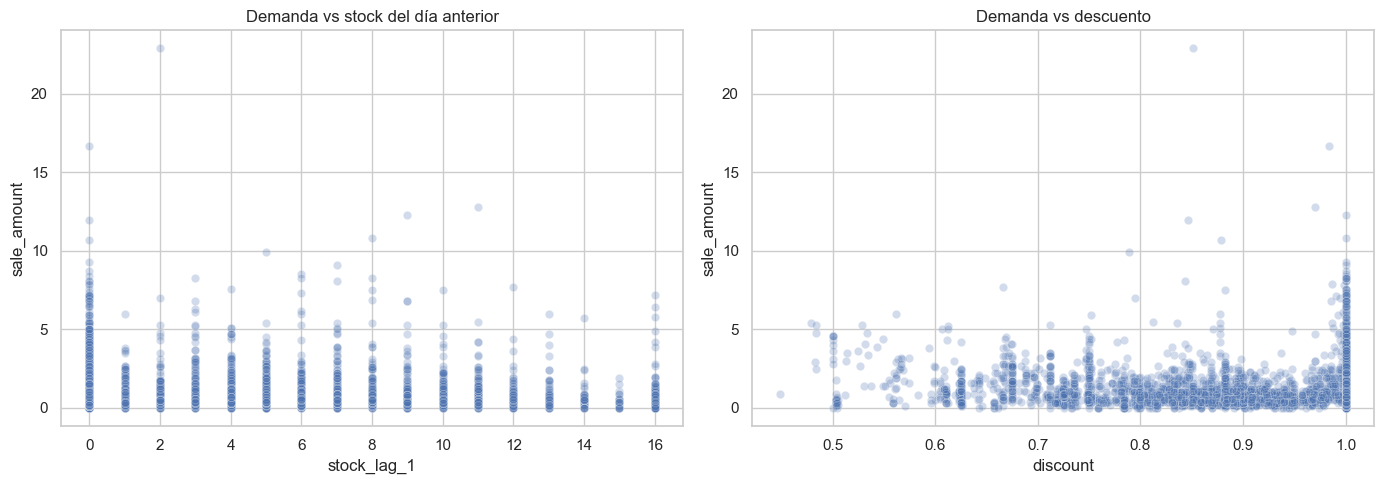


Demanda según holiday_flag:


,count,mean,median,sum
holiday_flag,,,,
0,65554,0.953851,0.6,62528.76
1,34446,1.180681,0.8,40669.75



Demanda según activity_flag:


,count,mean,median,sum
activity_flag,,,,
0,60096,1.009569,0.6,60671.03
1,39904,1.065745,0.8,42527.48



Demanda según hours_stock_status:


,count,mean,median,sum
hours_stock_status,,,,
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0],38886,1.014255,0.70,39440.33
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1],371,1.152291,0.80,427.50
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0],8,2.500000,1.60,20.00
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1],593,1.256003,0.80,744.81
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0],9,1.730000,0.80,15.57
...,...,...,...,...
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0],5,0.094000,0.07,0.47
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0],1,0.000000,0.00,0.00
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0],6,0.166667,0.20,1.00


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df.sample(min(5000, len(df)), random_state=42),
    x="stock_lag_1",
    y="sale_amount",
    alpha=0.25,
    ax=axes[0],
)
axes[0].set_title("Demanda vs stock del día anterior")

sns.scatterplot(
    data=df.sample(min(5000, len(df)), random_state=42),
    x="discount",
    y="sale_amount",
    alpha=0.25,
    ax=axes[1],
)
axes[1].set_title("Demanda vs descuento")

plt.tight_layout()
plt.show()

## 10. Visualización de demanda por feriado, actividad y estado de stock

In [ ]:
columnas_grupo = [
    col for col in ["holiday_flag", "activity_flag"]
    if col in df.columns
]

fig, axes = plt.subplots(1, len(columnas_grupo), figsize=(6 * len(columnas_grupo), 5))

if len(columnas_grupo) == 1:
    axes = [axes]

for ax, col in zip(axes, columnas_grupo):
    resumen = (
        df.groupby(col, observed=True)["sale_amount"]
        .agg(count="count", mean="mean", median="median", sum="sum")
        .reset_index()
        .sort_values(col)
    )

    sns.barplot(data=resumen, x=col, y="mean", ax=ax, color="#378ADD")
    ax.set_title(f"Demanda promedio según {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Demanda promedio")
    ax.tick_params(axis="x", rotation=30)

    for i, fila in resumen.reset_index(drop=True).iterrows():
        ax.text(
            i,
            fila["mean"],
            f"n={int(fila['count']):,}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
plt.show()

for col in columnas_grupo:
    print(f"\nResumen de demanda según {col}:")
    display(df.groupby(col, observed=True)["sale_amount"].agg(["count", "mean", "median", "sum"]))

## 11. Resumen interpretable de `hours_stock_status`

`hours_stock_status` no se grafica como categoría directa porque contiene patrones horarios codificados. En su lugar, se resume según la cantidad de horas con stock disponible.

In [ ]:
import re

def contar_horas_con_stock(valor):
    if pd.isna(valor):
        return np.nan

    numeros = re.findall(r"[-+]?\d*\.\d+|[-+]?\d+", str(valor))
    if not numeros:
        return np.nan

    valores = np.array([float(numero) for numero in numeros])
    return np.sum(valores > 0)

if "hours_stock_status" in df.columns:
    df["horas_con_stock"] = df["hours_stock_status"].apply(contar_horas_con_stock)

    df["nivel_disponibilidad_stock"] = pd.cut(
        df["horas_con_stock"],
        bins=[-0.1, 0, 8, 16, 24],
        labels=["Sin stock", "Baja", "Media", "Alta"],
    )

    resumen_stock = (
        df.groupby("nivel_disponibilidad_stock", observed=True)["sale_amount"]
        .agg(count="count", mean="mean", median="median", sum="sum")
        .reset_index()
    )

    display(resumen_stock)

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=resumen_stock,
        x="nivel_disponibilidad_stock",
        y="mean",
        color="#378ADD",
    )
    plt.title("Demanda promedio según disponibilidad de stock")
    plt.xlabel("Nivel de disponibilidad")
    plt.ylabel("Demanda promedio")

    for i, fila in resumen_stock.iterrows():
        plt.text(
            i,
            fila["mean"],
            f"n={int(fila['count']):,}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=df.sample(min(5000, len(df)), random_state=42),
        x="horas_con_stock",
        y="sale_amount",
        alpha=0.3,
    )
    plt.title("Demanda vs horas con stock disponible")
    plt.xlabel("Horas con stock")
    plt.ylabel("Demanda")
    plt.tight_layout()
    plt.show()

## 12. Correlación entre variables numéricas

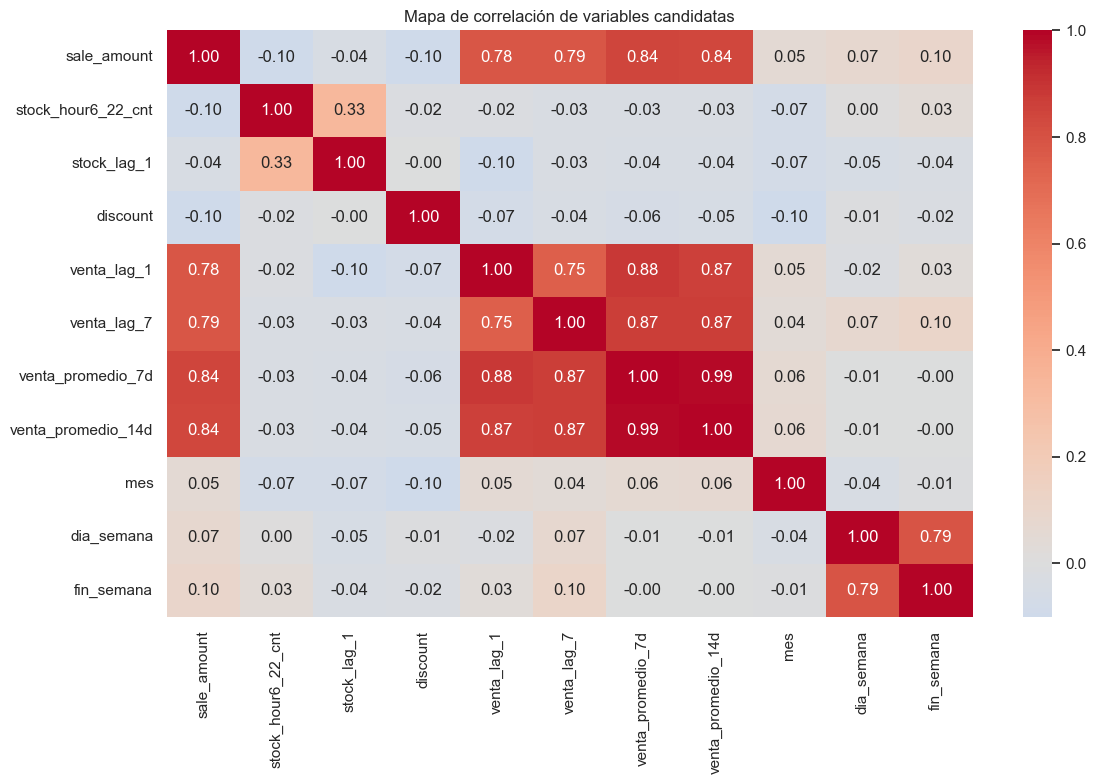

In [26]:
COLUMNAS_NUMERICAS_EDA = [
    "sale_amount",
    "stock_hour6_22_cnt",
    "stock_lag_1",
    "discount",
    "venta_lag_1",
    "venta_lag_7",
    "venta_promedio_7d",
    "venta_promedio_14d",
    "mes",
    "dia_semana",
    "fin_semana",
]

columnas_corr = [col for col in COLUMNAS_NUMERICAS_EDA if col in df.columns]
corr = df[columnas_corr].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Mapa de correlación de variables candidatas")
plt.tight_layout()
plt.show()

## 13. Variables candidatas para el modelo

In [27]:
TARGET = "sale_amount"

FEATURES_CANDIDATAS = [
    "product_id",
    "store_id",
    "first_category_id",
    "second_category_id",
    "third_category_id",
    "discount",
    "holiday_flag",
    "activity_flag",
    "mes",
    "dia_mes",
    "dia_semana",
    "fin_semana",
    "horas_con_stock",
    "venta_lag_1",
    "venta_lag_7",
    "venta_promedio_7d",
    "venta_promedio_14d",
    "stock_lag_1",
]

features_existentes = [col for col in FEATURES_CANDIDATAS if col in df.columns]

df_modelo_eda = df[["dt", TARGET] + features_existentes + [
    col for col in ["nombre_producto", "nombre_tienda", "nombre_categoria_n1"] if col in df.columns
]].copy()

print("Target:", TARGET)
print("Features candidatas:")
for feature in features_existentes:
    print("-", feature)

print("\nFilas sin rezagos suficientes:")
display(df_modelo_eda[features_existentes].isna().sum().sort_values(ascending=False).to_frame("nulos"))

display(df_modelo_eda.head())

Target: sale_amount
Features candidatas:
- product_id
- store_id
- first_category_id
- second_category_id
- third_category_id
- discount
- holiday_flag
- activity_flag
- mes
- dia_mes
- dia_semana
- fin_semana
- venta_lag_1
- venta_lag_7
- venta_promedio_7d
- venta_promedio_14d
- stock_lag_1

Filas sin rezagos suficientes:


,nulos
venta_lag_7,7784
stock_lag_1,1112
venta_promedio_14d,1112
venta_lag_1,1112
venta_promedio_7d,1112
product_id,0
store_id,0
second_category_id,0
first_category_id,0
mes,0


,dt,sale_amount,product_id,store_id,first_category_id,second_category_id,third_category_id,discount,holiday_flag,activity_flag,mes,dia_mes,dia_semana,fin_semana,venta_lag_1,venta_lag_7,venta_promedio_7d,venta_promedio_14d,stock_lag_1,nombre_producto,nombre_tienda,nombre_categoria_n1
0,2024-03-28,0.5,4,0,29,78,82,0.882,0,1,3,28,3,0,NaN,NaN,NaN,NaN,NaN,Producto 0109,Tienda 001,Categoría N1 018
1,2024-03-29,1.3,4,0,29,78,82,0.882,0,1,3,29,4,0,0.5,NaN,0.500000,0.500000,13.0,Producto 0109,Tienda 001,Categoría N1 018
2,2024-03-30,5.3,4,0,29,78,82,0.882,1,1,3,30,5,1,1.3,NaN,0.900000,0.900000,5.0,Producto 0109,Tienda 001,Categoría N1 018
3,2024-03-31,4.2,4,0,29,78,82,0.879,1,1,3,31,6,1,5.3,NaN,2.366667,2.366667,0.0,Producto 0109,Tienda 001,Categoría N1 018
4,2024-04-01,0.7,4,0,29,78,82,0.882,0,1,4,1,0,0,4.2,NaN,2.825000,2.825000,0.0,Producto 0109,Tienda 001,Categoría N1 018


## 14. Conclusiones iniciales del EDA

- Se mantiene la lógica útil del notebook logístico: revisión de estructura, nulos, duplicados, distribución, outliers, correlación y análisis de stock.
- Se elimina la generación sintética de medicamentos porque este dataset ya tiene mayor volumen.
- No se usa división aleatoria para el futuro modelo; la evaluación debe ser cronológica.
- La variable objetivo será `sale_amount`.
- Las variables de mayor valor para predicción temporal serán los rezagos y promedios móviles de ventas.
- Los nombres visuales sirven para la página, no para entrenar como números.